### 🤖 Guía de Asistencia con IA: IA como Copiloto de Programación

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Explicación de código**: Si encuentras una función o línea que no comprendes, pregúntale a la IA: *'Explica qué hace esta función línea por línea en Python: [pega tu código]'*.
- **Corrección de errores**: Si tienes un error al ejecutar, copia el error completo y pregúntale: *'¿Por qué este código genera este error y cómo lo soluciono? [pega tu código y error]'*.
- **Optimización**: Pregunta: *'¿Cómo puedo escribir este código de forma más eficiente y limpia?'*.


# Programa Ingenias+ Data Science



In [66]:
#import emoji
%pip install emoji

Note: you may need to restart the kernel to use updated packages.


In [67]:
import emoji

print(emoji.emojize("Python es genial :thumbs_up:"))

Python es genial 👍


Recordemos que un proyecto de data science tiene varias etapas:

1. Recolección de Datos
2. Exploración y Procesamiento de los datos
3. Modelado
4. Puesta en Producción

En clases anteriores, trabajamos con el dataset `StudentPerformace`. Pudimos observar el tipo de datos que teniamos y le hiciemos algunas transformaciones.

Llego la hora de utilizar los conceptos de aprendizaje supervisado para hacer predicciones sobre alguna variable en el dataset.

Para poder ajustar modelos de Machine Learning, la herramienta más sencilla y más utilizada es `scikit-learn`. Esta librería es muy utilizada ya que contiene funciones desarrolladas para la mayoría de los modelos de machine learning. Además `Scikit-learn` tienen una amplia y muy buena [documentación](https://scikit-learn.org/stable/).

<font size=5> 🚀 👩🏽‍💻 Machine Learning: Aprendizaje Supervisado 📣</font>

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

In [69]:
import os

In [70]:
os.getcwd()

'/home/leaolarte/Curso_YPF_Data_Science'

Primero, vamos a leer los datos limpios y procesados.

In [71]:
# Leemos nuevamente los datos de los estudiantes
students = pd.read_csv("DataSets/StudentsPerformance.csv")

In [72]:
students.head()

,Unnamed: 0,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,female,group B,bachelor's degree,standard,none,7.2,72,74
1,1,female,group C,some college,standard,completed,6.9,90,88
2,2,female,group B,master's degree,standard,none,9.0,95,93
3,3,male,group A,associate's degree,free/reduced,none,4.7,57,44
4,4,male,group C,some college,standard,none,7.6,78,75


Antes que nada, chequeemos nuevamente que eliminamos todos los valores faltantes.

In [73]:
students.isnull().sum()

Unnamed: 0                     0
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Ahora tenemos que decidir que variable o variables vamos a predecir. Esto quiere decir que tenemos que elegir cual va a ser la variable que al predecirla conteste la pregunta que nos hicimos de los datos.

Lo que queremos saber es:

1. ¿Qué puntaje final obtendra un estudiante?
2. Dado un estudiante, ¿aprobara o no el examen?

**_¿Qué tipo de problemas estamos tratando de resolver?_**

Para contestar estas preguntas vamos a obtener dos nuevas variables:

1. El puntaje final: Lo obtendremos promediando los tres puntajes (matematica, lectura y escritura)
2. Aprobado: Una etiqueta que me permita saber si cada estudiante del dataset aprobo el examen (puntaje final >= 60) o no lo aprobo (puntaje final < 60).

## 🟢 🟣 🟡 Clasificación

Contestaremos ahora la pregunta 2. Este problema es un problema de clasificación (_¿Por qué?_)

Lo primero que veremos es si tenemos un desbalance de clases. Es muy importante ver que no tenemos una clase minoritaria, ya que esto afectaria el algoritmo. En nuestro caso, que trabajamos con una clasificación binaria, tener un desbalance de clases implica que tenemos menos del 10% de nuestros datos que pertenecen a una de las clases.

In [74]:
# Crear el puntaje final
students['puntaje_final'] = (
    students['math score']
    + students['reading score']
    + students['writing score']
) / 3

# Crear la variable de clasificación
students['aprobado'] = (students['puntaje_final'] >= 60).astype(int)

In [75]:
xc = students.drop(
    ['math score', 'reading score', 'writing score',
     'puntaje_final', 'aprobado'],
    axis=1
)

In [76]:
students['aprobado'] = students['puntaje_final'].apply(lambda x: 0 if x < 60 else 1)

In [77]:
print(students.columns)

Index(['Unnamed: 0', 'gender', 'race/ethnicity', 'parental level of education',
       'lunch', 'test preparation course', 'math score', 'reading score',
       'writing score', 'puntaje_final', 'aprobado'],
      dtype='str')


In [78]:
students.head()

,Unnamed: 0,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,puntaje_final,aprobado
0,0,female,group B,bachelor's degree,standard,none,7.2,72,74,51.066667,0
1,1,female,group C,some college,standard,completed,6.9,90,88,61.633333,1
2,2,female,group B,master's degree,standard,none,9.0,95,93,65.666667,1
3,3,male,group A,associate's degree,free/reduced,none,4.7,57,44,35.233333,0
4,4,male,group C,some college,standard,none,7.6,78,75,53.533333,0


/tmp/ipykernel_39746/1017445476.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=students['aprobado'], palette='Set2')


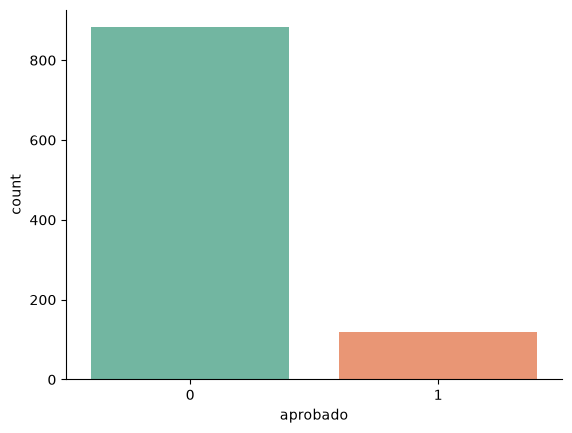

In [79]:
sns.countplot(x=students['aprobado'], palette='Set2')
sns.despine()

In [80]:
students['aprobado'].value_counts() / students['aprobado'].size * 100

aprobado
0    88.2
1    11.8
Name: count, dtype: float64

Como vemos que no tenemos un desbalance, podemos continuar.

#### Seleccion de target (y) y variables (X)

Ahora seleccionaremos las variables o features que deseemos usar como variable independientes y la variable a predecir.

Usaremos todas las variables menos aquellas que fueron usadas para calcular el puntaje final. Debemos también asegurarnos de no incluir las variables a predecir. Como variable a predecir usaremos `aprobado`.

In [81]:
# Variables predictoras
xc = students.drop(
    ['math score', 'reading score', 'writing score',
     'puntaje_final', 'aprobado'],
    axis=1
)

xc = pd.get_dummies(xc, dtype=int)
yc = students['aprobado']

xc, yc = np.array(xc), np.array(yc)

#### Separando Train / Test

Separamos nuevamente el dataset en entrenamiento y testeo o evaluación.

In [82]:
# prompt: agregar 'train_test_split'

from sklearn.model_selection import train_test_split




In [83]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(xc, yc, test_size=0.2,
                                                    random_state=42)

### Clasificador kNN

Para realizar la clasificación utilizaremos el algoritmo de los k-vecinos más cercanos.

In [84]:
from sklearn.neighbors import KNeighborsClassifier

In [85]:
# metricas
from sklearn.metrics import accuracy_score

In [86]:
knn = KNeighborsClassifier()

In [87]:
# Entrenamos el modelo
knn.fit(X_train_c, y_train_c);

In [88]:
# Predecimos
predicciones_cla = knn.predict(X_test_c)

In [89]:
accuracy = accuracy_score(y_test_c, predicciones_cla)*100
print(f'{round(accuracy, 2)}%')

91.5%


### Random Forest

Ahora utilizaremos Random Forest, pero en su versión Clasificacion.

In [90]:
from sklearn.ensemble import RandomForestClassifier

In [91]:
rf_cla = RandomForestClassifier()

In [92]:
# Entrenamos el modelo
rf_cla.fit(X_train_c, y_train_c);

In [93]:
# Predecimos
predicciones_rf = rf_cla.predict(X_test_c)

In [94]:
accuracy = accuracy_score(y_test_c, predicciones_rf)*100
print(f'{round(accuracy, 2)}%')

88.0%
